In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import pickle

from sklearn.model_selection        import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing          import LabelEncoder, StandardScaler
from sklearn.linear_model           import LogisticRegression
from sklearn.ensemble               import RandomForestClassifier
from sklearn.metrics                import (
    classification_report, confusion_matrix,
    precision_recall_curve, f1_score,
    ConfusionMatrixDisplay, roc_auc_score
)
from imblearn.over_sampling         import SMOTE
from xgboost                        import XGBClassifier

warnings.filterwarnings("ignore")

In [2]:
# ─────────────────────────────────────────────
# 0. CONFIGURATION
# ─────────────────────────────────────────────
DATASET_PATH = "../CNS Dataset/Processed/processed_network_dataset.csv"
RANDOM_STATE = 42
TEST_SIZE    = 0.2


# ─────────────────────────────────────────────
# 1. LOAD & INSPECT DATA
# ─────────────────────────────────────────────
print("=" * 60)
print("  STEP 1: Loading Data")
print("=" * 60)

df = pd.read_csv(DATASET_PATH)
df.columns = df.columns.str.strip()

print(f"Dataset shape  : {df.shape}")
print(f"\nLabel distribution:\n{df['Label'].value_counts()}")
print(f"\nClass balance  :\n{df['Label'].value_counts(normalize=True).mul(100).round(2)}%")

  STEP 1: Loading Data
Dataset shape  : (223082, 21)

Label distribution:
Label
DDoS      128014
BENIGN     95068
Name: count, dtype: int64

Class balance  :
Label
DDoS      57.38
BENIGN    42.62
Name: proportion, dtype: float64%


In [3]:
# ─────────────────────────────────────────────
# 2. FEATURE / LABEL SPLIT
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 2: Preparing Features & Labels")
print("=" * 60)

X = df.drop("Label", axis=1)
y_raw = df["Label"]

encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)

# Store class names for reporting
class_names = list(encoder.classes_)
print(f"Classes  : {class_names}")
print(f"Encoding : { {cls: idx for idx, cls in enumerate(class_names)} }")


  STEP 2: Preparing Features & Labels
Classes  : ['BENIGN', 'DDoS']
Encoding : {'BENIGN': 0, 'DDoS': 1}


In [4]:
# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


# ─────────────────────────────────────────────
# 4. SCALING (required for Logistic Regression)
# ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Training samples : 178465
Testing  samples : 44617


In [5]:
# ─────────────────────────────────────────────
# 5. HANDLING CLASS IMBALANCE WITH SMOTE
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 3: Applying SMOTE (Class Imbalance Handling)")
print("=" * 60)

print(f"\nBefore SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"After  SMOTE: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")
print("✓ Classes are now balanced for training.")

# For tree models (RF, XGB), use unscaled + resampled data
X_train_res_raw, y_train_res_raw = smote.fit_resample(X_train, y_train)


  STEP 3: Applying SMOTE (Class Imbalance Handling)

Before SMOTE: {np.int64(0): np.int64(76054), np.int64(1): np.int64(102411)}
After  SMOTE: {np.int64(0): np.int64(102411), np.int64(1): np.int64(102411)}
✓ Classes are now balanced for training.


In [6]:
# ─────────────────────────────────────────────
# 6. TRAIN THREE MODELS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 4: Training Models")
print("=" * 60)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced"          # extra safety on imbalance
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}


  STEP 4: Training Models


In [7]:
results       = {}
trained_models = {}

for name, model in models.items():
    print(f"\n  ▶ Training {name}...")

    if name == "Logistic Regression":
        model.fit(X_train_res, y_train_res)
        y_pred      = model.predict(X_test_scaled)
        y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_res_raw, y_train_res_raw)
        y_pred      = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    f1  = f1_score(y_test, y_pred, average="weighted")
    auc = roc_auc_score(y_test, y_pred_prob)
    report = classification_report(y_test, y_pred, target_names=class_names)

    results[name] = {
        "F1 Score (weighted)" : round(f1, 4),
        "ROC-AUC"             : round(auc, 4),
        "y_pred"              : y_pred,
        "y_pred_prob"         : y_pred_prob,
        "report"              : report,
    }
    trained_models[name] = model

    print(f"     F1  Score : {f1:.4f}")
    print(f"     ROC-AUC   : {auc:.4f}")
    print(f"\n{report}")


  ▶ Training Logistic Regression...
     F1  Score : 0.9982
     ROC-AUC   : 0.9997

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19014
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617


  ▶ Training Random Forest...
     F1  Score : 0.9997
     ROC-AUC   : 1.0000

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19014
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617


  ▶ Training XGBoost...
     F1  Score : 0.9998
     ROC-AUC   : 1.0000

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     190

In [8]:
# ─────────────────────────────────────────────
# 7. MODEL COMPARISON TABLE
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 5: Model Comparison")
print("=" * 60)

comparison_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ("y_pred", "y_pred_prob", "report")}
    for name, res in results.items()
}).T

print(comparison_df.to_string())

comparison_df.to_csv("../Metrics/model_comparison_report.csv", index=True)
print("\n✓ Saved → model_comparison_report.csv")


  STEP 5: Model Comparison
                     F1 Score (weighted)  ROC-AUC
Logistic Regression               0.9982   0.9997
Random Forest                     0.9997   1.0000
XGBoost                           0.9998   1.0000

✓ Saved → model_comparison_report.csv



  STEP 6: Plotting Confusion Matrices


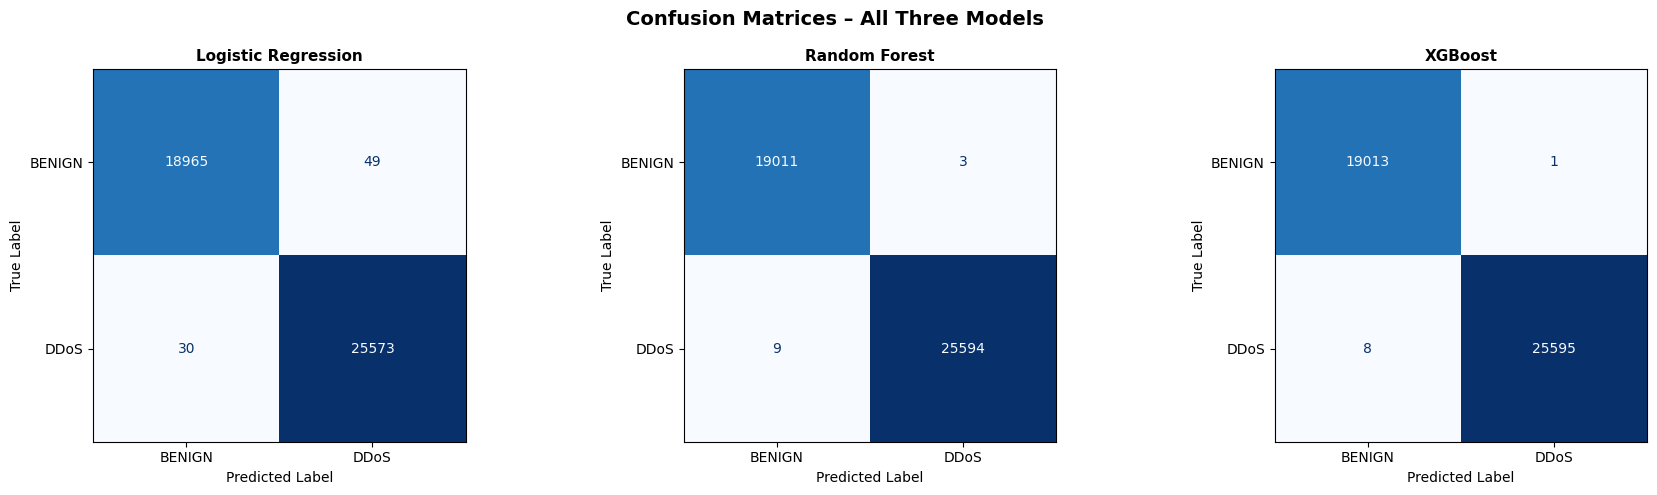

✓ Saved → confusion_matrices.png


In [9]:
# ─────────────────────────────────────────────
# 8. CONFUSION MATRICES PLOT
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 6: Plotting Confusion Matrices")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices – All Three Models", fontsize=14, fontweight="bold")

for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("../Metrics/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → confusion_matrices.png")


  STEP 7: False Positive Reduction — Threshold Tuning

  Best model selected: XGBoost

  Optimal Threshold (FPR < 5%): 0.11
  At this threshold:
    Precision : 0.9996
    Recall    : 1.0000
    F1 Score  : 0.9998
    FP Rate   : 0.0006


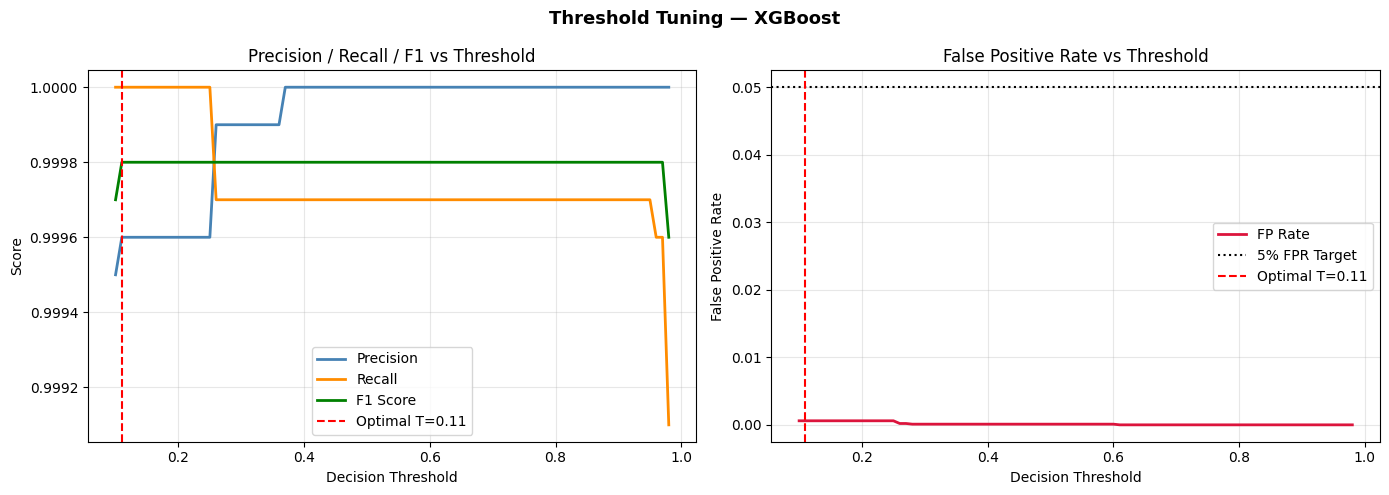


✓ Saved → threshold_analysis.png


In [10]:
# ─────────────────────────────────────────────
# 9. FALSE POSITIVE REDUCTION – THRESHOLD TUNING
#    (Using the best model by F1)
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 7: False Positive Reduction — Threshold Tuning")
print("=" * 60)

best_name = max(results, key=lambda k: results[k]["F1 Score (weighted)"])
print(f"\n  Best model selected: {best_name}")

best_probs = results[best_name]["y_pred_prob"]

# Compute precision, recall, F1 across thresholds
thresholds  = np.arange(0.1, 0.99, 0.01)
precisions, recalls, f1_scores, fp_rates = [], [], [], []

# Identify which class index represents ATTACK (non-BENIGN)
benign_idx  = list(encoder.classes_).index("BENIGN")
attack_idx  = 1 - benign_idx   # works for binary

for t in thresholds:
    y_pred_t = (best_probs >= t).astype(int)

    # In binary: attack_idx=1, benign_idx=0
    # For multi-class this would need adjustment
    prec = np.sum((y_pred_t == attack_idx) & (y_test == attack_idx)) / \
           (np.sum(y_pred_t == attack_idx) + 1e-9)
    rec  = np.sum((y_pred_t == attack_idx) & (y_test == attack_idx)) / \
           (np.sum(y_test == attack_idx) + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)

    # False Positive Rate = FP / (FP + TN)
    fp   = np.sum((y_pred_t == attack_idx) & (y_test == benign_idx))
    tn   = np.sum((y_pred_t == benign_idx) & (y_test == benign_idx))
    fpr  = fp / (fp + tn + 1e-9)

    precisions.append(round(prec, 4))
    recalls.append(round(rec, 4))
    f1_scores.append(round(f1, 4))
    fp_rates.append(round(fpr, 4))

# Find the optimal threshold: highest F1 with FPR < 5%
optimal_idx = max(
    range(len(thresholds)),
    key=lambda i: f1_scores[i] if fp_rates[i] < 0.05 else 0
)
optimal_threshold = round(thresholds[optimal_idx], 2)

print(f"\n  Optimal Threshold (FPR < 5%): {optimal_threshold}")
print(f"  At this threshold:")
print(f"    Precision : {precisions[optimal_idx]:.4f}")
print(f"    Recall    : {recalls[optimal_idx]:.4f}")
print(f"    F1 Score  : {f1_scores[optimal_idx]:.4f}")
print(f"    FP Rate   : {fp_rates[optimal_idx]:.4f}")

# ── Plot threshold analysis ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Threshold Tuning — {best_name}", fontsize=13, fontweight="bold")

# Left: Precision, Recall, F1 vs Threshold
ax1 = axes[0]
ax1.plot(thresholds, precisions, label="Precision",  color="steelblue",  linewidth=2)
ax1.plot(thresholds, recalls,    label="Recall",     color="darkorange", linewidth=2)
ax1.plot(thresholds, f1_scores,  label="F1 Score",   color="green",      linewidth=2)
ax1.axvline(optimal_threshold, color="red", linestyle="--", linewidth=1.5,
            label=f"Optimal T={optimal_threshold}")
ax1.set_xlabel("Decision Threshold")
ax1.set_ylabel("Score")
ax1.set_title("Precision / Recall / F1 vs Threshold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: False Positive Rate vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, fp_rates, color="crimson", linewidth=2, label="FP Rate")
ax2.axhline(0.05, color="black", linestyle=":", linewidth=1.5, label="5% FPR Target")
ax2.axvline(optimal_threshold, color="red", linestyle="--", linewidth=1.5,
            label=f"Optimal T={optimal_threshold}")
ax2.set_xlabel("Decision Threshold")
ax2.set_ylabel("False Positive Rate")
ax2.set_title("False Positive Rate vs Threshold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../Metrics/threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Saved → threshold_analysis.png")

In [11]:
# ─────────────────────────────────────────────
# 10. APPLY OPTIMAL THRESHOLD & FINAL REPORT
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 8: Final Classification Report (Optimal Threshold)")
print("=" * 60)

y_pred_optimal = (best_probs >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal, target_names=class_names))


  STEP 8: Final Classification Report (Optimal Threshold)
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19014
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617



In [12]:
# ─────────────────────────────────────────────
# 11. SAVE BEST MODEL & SCALER
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 9: Saving Best Model & Scaler")
print("=" * 60)

best_model = trained_models[best_name]

with open("../models/best_model.pkl", "wb") as f:
    pickle.dump({
        "model"             : best_model,
        "scaler"            : scaler,
        "encoder"           : encoder,
        "optimal_threshold" : optimal_threshold,
        "top_features"      : list(X.columns)
    }, f)

print(f"✓ Best model ({best_name}) saved → best_model.pkl")
print("\n  This file contains:")
print("    - Trained model")
print("    - Scaler (for Logistic Regression path)")
print("    - Label encoder")
print("    - Optimal decision threshold")
print("    - Feature list (for Member 3's dashboard)\n")


  STEP 9: Saving Best Model & Scaler
✓ Best model (XGBoost) saved → best_model.pkl

  This file contains:
    - Trained model
    - Scaler (for Logistic Regression path)
    - Label encoder
    - Optimal decision threshold
    - Feature list (for Member 3's dashboard)

